# Setup

Please ensure you have imported a Gemini API key from AI Studio.
You can do this directly in the Secrets tab on the left.

After doing so, please run the setup cell below.

In [ ]:
from langchain_groq import ChatGroq

In [ ]:
import re
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

# Define the rubric criteria and their score descriptions
criteria_descriptions = {
    "Accuracy of Information": {
        "5": "Completely accurate with no errors.",
        "4": "Mostly accurate with minor inaccuracies.",
        "3": "Contains some accurate information but includes significant errors.",
        "2": "Mostly inaccurate with only a few correct points.",
        "1": "Completely inaccurate."
    },
    "Depth of Understanding": {
        "5": "Demonstrates a thorough and insightful understanding.",
        "4": "Shows a good understanding with some depth.",
        "3": "Reflects a basic understanding with little depth.",
        "2": "Superficial understanding, lacking substance.",
        "1": "No understanding demonstrated."
    },
    "Clarity and Coherence": {
        "5": "Exceptionally clear, concise, and well-structured.",
        "4": "Clear with minor structural or wording issues.",
        "3": "Somewhat clear but with noticeable structural problems.",
        "2": "Unclear and poorly structured, difficult to follow.",
        "1": "Completely unclear and incoherent."
    },
    "Relevance": {
        "5": "Directly and fully addresses the question with no irrelevant content.",
        "4": "Mostly addresses the question with minor deviations.",
        "3": "Partially addresses the question but includes some irrelevant content.",
        "2": "Barely addresses the question, dominated by irrelevant information.",
        "1": "Does not address the question at all."
    },
    "Use of Examples": {
        "5": "Provides highly relevant and illustrative examples.",
        "4": "Includes relevant examples with minor issues.",
        "3": "Offers somewhat relevant examples that partially support the answer.",
        "2": "Provides poorly chosen or irrelevant examples.",
        "1": "No examples provided."
    }
}

def score_answer(answer, question=None):
    """
    Scores a short answer using the ChatGroq model based on the defined rubric.

    Args:
        answer (str): The student's answer to be scored.
        question (str, optional): The question the answer is responding to.

    Returns:
        tuple: (scores, justifications) where scores is a dict of criterion:score,
               and justifications is a dict of criterion:justification.
    """
    # Create the prompt
    prompt = "Score the following answer based on the rubric criteria and provide a brief justification for each score.\n\n"
    prompt += "**Criteria**:\n"
    for criterion in criteria_descriptions:
        prompt += f"- {criterion}\n"
    prompt += "\n**Score Descriptions**:\n"
    for criterion, scores in criteria_descriptions.items():
        prompt += f"{criterion}:\n"
        for score, desc in scores.items():
            prompt += f"  {score}: {desc}\n"
    if question:
        prompt += f"\n**Question**: {question}\n"
    prompt += f"**Answer**: {answer}\n\n"
    prompt += "Provide the scores and justifications in this format:\n"
    for criterion in criteria_descriptions:
        prompt += f"{criterion}: [score] - [justification]\n"

    # Initialize ChatGroq
    chat_groq = ChatGroq(
        model="qwen-qwq-32b",
        api_key="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"
    )

    # Prepare the messages as a list of BaseMessage objects
    messages = [HumanMessage(content=prompt)]

    # Call the ChatGroq model with the list of messages
    response = chat_groq.invoke(messages)

    # Extract the response text
    response_text = response.content

    # Parse the response
    scores = {}
    justifications = {}
    for criterion in criteria_descriptions:
        pattern = rf"{criterion}:\s*(\d)\s*-\s*(.+?)(?=\n(?:\w+\s*:\s*\d)|$)"
        match = re.search(pattern, response_text, re.DOTALL)
        if match:
            scores[criterion] = int(match.group(1))
            justifications[criterion] = match.group(2).strip()
        else:
            scores[criterion] = None
            justifications[criterion] = "No justification provided."

    return scores, justifications

# Example usage
question = "What is the difference between supervised and unsupervised learning?"
answer = "Supervised learning uses labeled data to train models, while unsupervised learning uses unlabeled data to find patterns."
scores, justifications = score_answer(answer, question)

# Print the results
print("Scoring Results:")
for criterion in scores:
    print(f"{criterion}: {scores[criterion]} - {justifications[criterion]}")

Scoring Results:
Accuracy of Information: 5 - The answer correctly identifies the core distinction between supervised (labeled data) and unsupervised learning (unlabeled data), with no inaccuracies.  
Depth of Understanding: 4 - The answer demonstrates a good understanding of the fundamental difference but does not explore additional nuances, such as specific algorithms, use cases, or outcomes (e.g., classification vs. clustering). However, it sufficiently addresses the question's core requirement.  
Clarity and Coherence: 5 - The response is concise, direct, and free of ambiguity, clearly contrasting the two concepts without redundancy or confusion.
Depth of Understanding: 4 - The answer demonstrates a good understanding of the fundamental difference but does not explore additional nuances, such as specific algorithms, use cases, or outcomes (e.g., classification vs. clustering). However, it sufficiently addresses the question's core requirement.  
Clarity and Coherence: 5 - The respo

In [ ]:
import re
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END
from typing import TypedDict

# Define the rubric criteria and their score descriptions
criteria_descriptions = {
    "Accuracy of Information": {
        "5": "Completely accurate with no errors.",
        "4": "Mostly accurate with minor inaccuracies.",
        "3": "Contains some accurate information but includes significant errors.",
        "2": "Mostly inaccurate with only a few correct points.",
        "1": "Completely inaccurate."
    },
    "Depth of Understanding": {
        "5": "Demonstrates a thorough and insightful understanding.",
        "4": "Shows a good understanding with some depth.",
        "3": "Reflects a basic understanding with little depth.",
        "2": "Superficial understanding, lacking substance.",
        "1": "No understanding demonstrated."
    },
    "Clarity and Coherence": {
        "5": "Exceptionally clear, concise, and well-structured.",
        "4": "Clear with minor structural or wording issues.",
        "3": "Somewhat clear but with noticeable structural problems.",
        "2": "Unclear and poorly structured, difficult to follow.",
        "1": "Completely unclear and incoherent."
    },
    "Relevance": {
        "5": "Directly and fully addresses the question with no irrelevant content.",
        "4": "Mostly addresses the question with minor deviations.",
        "3": "Partially addresses the question but includes some irrelevant content.",
        "2": "Barely addresses the question, dominated by irrelevant information.",
        "1": "Does not address the question at all."
    },
    "Use of Examples": {
        "5": "Provides highly relevant and illustrative examples.",
        "4": "Includes relevant examples with minor issues.",
        "3": "Offers somewhat relevant examples that partially support the answer.",
        "2": "Provides poorly chosen or irrelevant examples.",
        "1": "No examples provided."
    }
}

def score_answer(answer, question=None):
    """
    Scores an answer based on the rubric using ChatGroq and returns scores and justifications.
    """
    # Construct the prompt
    prompt = "Score the following answer based on the rubric criteria and provide a brief justification for each score.\n\n"
    prompt += "**Criteria**:\n"
    for criterion in criteria_descriptions:
        prompt += f"- {criterion}\n"
    prompt += "\n**Score Descriptions**:\n"
    for criterion, scores in criteria_descriptions.items():
        prompt += f"{criterion}:\n"
        for score, desc in scores.items():
            prompt += f"  {score}: {desc}\n"
    if question:
        prompt += f"\n**Question**: {question}\n"
    prompt += f"**Answer**: {answer}\n\n"
    prompt += "Provide the scores and justifications in this format:\n"
    for criterion in criteria_descriptions:
        prompt += f"{criterion}: [score] - [justification]\n"

    # Initialize ChatGroq (replace with your API key)
    chat_groq = ChatGroq(
        model="qwen-qwq-32b",
        api_key="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",
        temperature=0
    )

    # Prepare the messages
    messages = [HumanMessage(content=prompt)]

    # Call the ChatGroq model
    response = chat_groq.invoke(messages)

    # Extract the response text
    response_text = response.content

    # Parse the response
    scores = {}
    justifications = {}
    for criterion in criteria_descriptions:
        pattern = rf"{criterion}:\s*(\d)\s*-\s*(.+?)(?=\n(?:\w+\s*:\s*\d)|$)"
        match = re.search(pattern, response_text, re.DOTALL)
        if match:
            scores[criterion] = int(match.group(1))
            justifications[criterion] = match.group(2).strip()
        else:
            scores[criterion] = None
            justifications[criterion] = "No justification provided."

    return scores, justifications

# Define the state schema for LangGraph
class State(TypedDict):
    question: str
    answer: str
    scores: dict
    justifications: dict

def scoring_node(state: State) -> dict:
    """
    Scoring node that evaluates the answer and updates the state with scores and justifications.
    """
    question = state["question"]
    answer = state["answer"]
    scores, justifications = score_answer(answer, question)
    return {"scores": scores, "justifications": justifications}

# Set up the LangGraph agent
graph = StateGraph(State)
graph.add_node("scoring", scoring_node)
graph.set_entry_point("scoring")
graph.add_edge("scoring", END)
app = graph.compile()

# Example usage with the provided question and answer
question = "What is LoRA and QLoRA"
answer = ("""LoRA and QLoRA are techniques designed to optimize the fine
tuning of Large Language Models (LLMs), focusing on reducing
 memory usage and enhancing efficiency without compromising
 performance in Natural Language Processing (NLP) tasks.""")
initial_state = {"question": question, "answer": answer}
result = app.invoke(initial_state)

# Print the scoring results
print("Scoring Results:")
for criterion in result["scores"]:
    print(f"{criterion}: {result['scores'][criterion]} - {result['justifications'][criterion]}")

Scoring Results:
Accuracy of Information: 5 - The answer correctly identifies LoRA and QLoRA as techniques for optimizing fine-tuning of LLMs, emphasizing memory reduction and efficiency. There are no factual errors.  
Depth of Understanding: 3 - The explanation is basic, focusing on purpose but not explaining mechanisms (e.g., low-rank matrices for LoRA or quantization for QLoRA). It lacks technical depth.  
Clarity and Coherence: 5 - The answer is concise, well-structured, and free of ambiguity.
Depth of Understanding: 3 - The explanation is basic, focusing on purpose but not explaining mechanisms (e.g., low-rank matrices for LoRA or quantization for QLoRA). It lacks technical depth.  
Clarity and Coherence: 5 - The answer is concise, well-structured, and free of ambiguity.
Clarity and Coherence: 5 - The answer is concise, well-structured, and free of ambiguity.
Relevance: 5 - Directly addresses the question without irrelevant details.  
Use of Examples: 1 - No examples are provided 

In [ ]:
import re
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END
from typing import TypedDict

# Define the rubric criteria and their score descriptions
criteria_descriptions = {
    "Accuracy of Information": {
        "5": "Completely accurate with no errors.",
        "4": "Mostly accurate with minor inaccuracies.",
        "3": "Contains some accurate information but includes significant errors.",
        "2": "Mostly inaccurate with only a few correct points.",
        "1": "Completely inaccurate."
    },
    "Depth of Understanding": {
        "5": "Demonstrates a thorough and insightful understanding.",
        "4": "Shows a good understanding with some depth.",
        "3": "Reflects a basic understanding with little depth.",
        "2": "Superficial understanding, lacking substance.",
        "1": "No understanding demonstrated."
    },
    "Clarity and Coherence": {
        "5": "Exceptionally clear, concise, and well-structured.",
        "4": "Clear with minor structural or wording issues.",
        "3": "Somewhat clear but with noticeable structural problems.",
        "2": "Unclear and poorly structured, difficult to follow.",
        "1": "Completely unclear and incoherent."
    },
    "Relevance": {
        "5": "Directly and fully addresses the question with no irrelevant content.",
        "4": "Mostly addresses the question with minor deviations.",
        "3": "Partially addresses the question but includes some irrelevant content.",
        "2": "Barely addresses the question, dominated by irrelevant information.",
        "1": "Does not address the question at all."
    },
    "Use of Examples": {
        "5": "Provides highly relevant and illustrative examples.",
        "4": "Includes relevant examples with minor issues.",
        "3": "Offers somewhat relevant examples that partially support the answer.",
        "2": "Provides poorly chosen or irrelevant examples.",
        "1": "No examples provided."
    }
}

def score_answer(answer, question=None):
    """
    Scores an answer based on the rubric using ChatGroq and returns scores and justifications.
    """
    # Construct the prompt
    prompt = "Score the following answer based on the rubric criteria and provide a brief justification for each score.\n\n"
    prompt += "**Criteria**:\n"
    for criterion in criteria_descriptions:
        prompt += f"- {criterion}\n"
    prompt += "\n**Score Descriptions**:\n"
    for criterion, scores in criteria_descriptions.items():
        prompt += f"{criterion}:\n"
        for score, desc in scores.items():
            prompt += f"  {score}: {desc}\n"
    if question:
        prompt += f"\n**Question**: {question}\n"
    prompt += f"**Answer**: {answer}\n\n"
    prompt += "Provide the scores and justifications in this format:\n"
    for criterion in criteria_descriptions:
        prompt += f"{criterion}: [score] - [justification]\n"

    # Initialize ChatGroq (replace with your API key)
    chat_groq = ChatGroq(
        model="qwen-qwq-32b",
        api_key="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",
        temperature=0
    )

    # Prepare the messages
    messages = [HumanMessage(content=prompt)]

    # Call the ChatGroq model
    response = chat_groq.invoke(messages)

    # Extract the response text
    response_text = response.content

    # Parse the response
    scores = {}
    justifications = {}
    for criterion in criteria_descriptions:
        pattern = rf"{criterion}:\s*(\d)\s*-\s*(.+?)(?=\n(?:\w+\s*:\s*\d)|$)"
        match = re.search(pattern, response_text, re.DOTALL)
        if match:
            scores[criterion] = int(match.group(1))
            justifications[criterion] = match.group(2).strip()
        else:
            scores[criterion] = None
            justifications[criterion] = "No justification provided."

    return scores, justifications

# Define the state schema for LangGraph
class State(TypedDict):
    question: str
    answer: str
    scores: dict
    justifications: dict

def scoring_node(state: State) -> dict:
    """
    Scoring node that evaluates須the answer and updates the state with scores and justifications.
    """
    question = state["question"]
    answer = state["answer"]
    scores, justifications = score_answer(answer, question)
    return {"scores": scores, "justifications": justifications}

# Set up the LangGraph agent
graph = StateGraph(State)
graph.add_node("scoring", scoring_node)
graph.set_entry_point("scoring")
graph.add_edge("scoring", END)
app = graph.compile()

def parse_qa_text(text):
    """
    Parses the input text to extract question-answer pairs.
    Returns a list of dictionaries with 'number', 'question', and 'answer'.
    """
    qa_list = []
    parts = re.split(r"(Q\d+\.)", text)
    for i in range(1, len(parts), 2):
        number = parts[i].strip(".")
        question_part = parts[i+1].strip()
        answer_start = question_part.find("Ans -")
        if answer_start != -1:
            question = question_part[:answer_start].strip()
            answer = question_part[answer_start + len("Ans -"):].strip()
            qa_list.append({"number": number, "question": question, "answer": answer})
    return qa_list

# Main execution
if __name__ == "__main__":
    # Input text containing multiple question-answer pairs
    qa_text = """
    Q1. What is tokenization, and why is it important in LLMs?
    Ans - Tokenization is the process of splitting text into smaller units
    called tokens, which can be words, subwords, or even characters. For
    instance, the word “tokenization” might be broken down into smaller
    subwords like “token” and “ization.” This step is crucial because LLMs
    do not understand raw text directly. Instead, they process sequences
    of numbers that represent these tokens.
    Effective tokenization allows models to handle various languages,
    manage rare words, and reduce the vocabulary size, which improves
    both efficiency and performance.
    Image Source: Cognitive Class
    Bhavishya Pandit
    Q2. What is LoRA and QLoRA?
    Ans - LoRA and QLoRA are techniques designed to optimize the fine
    tuning of Large Language Models (LLMs), focusing on reducing
    memory usage and enhancing efficiency without compromising
    performance in Natural Language Processing (NLP) tasks.
    LoRA (Low-Rank Adaptation)
    LoRA is a parameter-efficient fine-tuning method that introduces
    new trainable parameters to modify a model's behavior without
    increasing its overall size. By doing so, LoRA maintains the original
    parameter count, reducing the memory overhead typically associated
    with training large models. It works by adding low-rank matrix
    adaptations to the model's existing layers, allowing for significant
    performance improvements while keeping resource consumption in
    check.
    Bhavishya Pandit
    This makes it ideal for environments where computational resources
    are limited, yet high model accuracy is still required.
    QLoRA (Quantized LoRA)
    QLoRA builds on LoRA by incorporating quantization to further
    optimize memory usage. It uses techniques such as 4-bit Normal
    Float, Double Quantization, and Paged Optimizers to compress the
    model's parameters and improve computational efficiency. By
    reducing the precision of model weights (e.g., from 16-bit to 4-bit)
    while retaining most of the model's accuracy, QLoRA allows for the
    fine-tuning of LLMs with minimal memory footprint. This method is
    particularly useful when scaling large models, as it maintains
    performance levels comparable to full-precision models while
    significantly reducing resource consumption.
    Bhavishya Pandit
    Bhavishya Pandit
    Q3. What is beam search, and how does it differ from greedy
    decoding?
    Ans - Beam search is a search algorithm used during text generation
    to find the most likely sequence of words. Instead of choosing the
    single highest-probability word at each step (as greedy decoding
    does), beam search explores multiple possible sequences in parallel,
    maintaining a set of the top k candidates (beams). It balances
    between finding high-probability sequences and exploring
    alternative paths. This leads to more coherent and contextually
    appropriate outputs, especially in long-form text generation tasks.
    Bhavishya Pandit
    Q4. Explain the concept of temperature in LLM text generation.
    Ans - Temperature is a hyperparameter that controls the randomness
    of text generation by adjusting the probability distribution over
    possible next tokens. A low temperature (close to 0) makes the
    model highly deterministic, favoring the most probable tokens.
    Conversely, a high temperature (above 1) encourages more diversity
    by flattening the distribution, allowing less probable tokens to be
    selected. For instance, a temperature of 0.7 strikes a balance
    between creativity and coherence, making it suitable for generating
    diverse but sensible outputs.
    Bhavishya Pandit
    Q5. What is masked language modeling, and how does it contribute
    to model pretraining?
    Ans - Masked language modeling (MLM) is a training objective where
    some tokens in the input are randomly masked, and the model is
    tasked with predicting them based on context. This forces the model
    to learn contextual relationships between words, enhancing its
    ability to understand language semantics. MLM is commonly used in
    models like BERT, which are pretrained using this objective to
    develop a deep understanding of language before fine-tuning on
    specific tasks.
    Q6. What are Sequence-to-Sequence Models?
    Ans - Sequence-to-Sequence (Seq2Seq) Models are a type of neural
    network architecture designed to transform one sequence of data
    into another sequence. These models are commonly used in tasks
    where the input and output have variable lengths, such as in machine
    translation, text summarization, and speech recognition.
    How are you?
    A good teacher must
    master these 3 qualities
    to become successful
    ..................................
    1.
    2.
    3.
    ..................................
    ..................................
    Cómo estás
    Chatbot
    Summarization
    Language Translation
    Bhavishya Pandit
    I am good.
    What about you?
    3 qualities of an
    excellent teacher
    How are you?
    Bhavishya Pandit
    Q7. How do autoregressive models differ from masked models in
    LLM training?
    Ans - Autoregressive models, such as GPT, generate text one token at
    a time, with each token predicted based on the previously generated
    tokens. This sequential approach is ideal for tasks like text
    generation. Masked models, like BERT, predict randomly masked
    tokens within a sentence, leveraging both left and right context.
    Autoregressive models excel in generative tasks, while masked
    models are better suited for understanding and classification tasks.
    Bhavishya Pandit
    Q8. What role do embeddings play in LLMs, and how are they
    initialized?
    Ans - Embeddings are dense, continuous vector representations of
    tokens, capturing semantic and syntactic information. They map
    discrete tokens (words or subwords) into a high-dimensional space,
    making them suitable for input into neural networks. Embeddings
    are typically initialized randomly or with pretrained vectors like
    Word2Vec or GloVe. During training, these embeddings are fine
    tuned to capture task-specific nuances, enhancing the model’s
    performance on various language tasks.
    Q9. What is next sentence prediction and how is useful in language
    modelling?
    Ans - Next Sentence Prediction (NSP) is a key technique used in
    language modeling, particularly in training large models like BERT
    (Bidirectional Encoder Representations from Transformers). NSP
    helps a model understand the relationship between two sentences,
    which is important for tasks like question answering, dialogue
    generation, and information retrieval.
    During pre-training, the model is fed two sentences:
    50% of the time, the second sentence is the actual next sentence in the document
    (positive pairs).
    50% of the time, the second sentence is a random sentence from the corpus
    (negative pairs). The model is trained to classify whether the second sentence is
    the correct next sentence or not. This binary classification task is used alongside a
    masked language modeling task to improve the model's overall language
    understanding.
    Bhavishya Pandit
    Bhavishya Pandit
    Q10. Explain the difference between top-k sampling and nucleus
    (top-p) sampling in LLMs.
    Ans - Top-k sampling restricts the model’s choices to the top k most
    probable tokens at each step, introducing controlled randomness.
    For example, setting k=10 means the model will only consider the 10
    most likely tokens. Nucleus sampling, or top-p sampling, takes a
    more dynamic approach by selecting tokens whose cumulative
    probability exceeds a threshold p (e.g., 0.9). This allows for flexible
    candidate sets based on context, promoting both diversity and
    coherence in generated text
    """

    # Parse the question-answer pairs
    qa_pairs = parse_qa_text(qa_text)

    # Process each pair and calculate the average score
    for pair in qa_pairs:
        initial_state = {"question": pair["question"], "answer": pair["answer"]}
        result = app.invoke(initial_state)
        scores = result["scores"]

        # Check if all scores are present
        if all(score is not None for score in scores.values()):
            average = sum(scores.values()) / len(scores)
            print(f"{pair['number']}: Average Score - {average:.2f}")
        else:
            print(f"{pair['number']}: Scoring incomplete")

Q1: Average Score - 4.40
Q2: Average Score - 3.20
Q3: Average Score - 4.00
Q4: Average Score - 4.80
Q5: Average Score - 5.00
Q6: Average Score - 2.40
Q7: Average Score - 4.60
Q8: Average Score - 5.00
Q9: Average Score - 4.00
Q10: Average Score - 5.00


In [ ]:
import re
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END
from typing import TypedDict

# Define the rubric criteria and their score descriptions
criteria_descriptions = {
    "Accuracy of Information": {
        "5": "Completely accurate with no errors.",
        "4": "Mostly accurate with minor inaccuracies.",
        "3": "Contains some accurate information but includes significant errors.",
        "2": "Mostly inaccurate with only a few correct points.",
        "1": "Completely inaccurate."
    },
    "Depth of Understanding": {
        "5": "Demonstrates a thorough and insightful understanding.",
        "4": "Shows a good understanding with some depth.",
        "3": "Reflects a basic understanding with little depth.",
        "2": "Superficial understanding, lacking substance.",
        "1": "No understanding demonstrated."
    },
    "Clarity and Coherence": {
        "5": "Exceptionally clear, concise, and well-structured.",
        "4": "Clear with minor structural or wording issues.",
        "3": "Somewhat clear but with noticeable structural problems.",
        "2": "Unclear and poorly structured, difficult to follow.",
        "1": "Completely unclear and incoherent."
    },
    "Relevance": {
        "5": "Directly and fully addresses the question with no irrelevant content.",
        "4": "Mostly addresses the question with minor deviations.",
        "3": "Partially addresses the question but includes some irrelevant content.",
        "2": "Barely addresses the question, dominated by irrelevant information.",
        "1": "Does not address the question at all."
    },
    "Use of Examples": {
        "5": "Provides highly relevant and illustrative examples.",
        "4": "Includes relevant examples with minor issues.",
        "3": "Offers somewhat relevant examples that partially support the answer.",
        "2": "Provides poorly chosen or irrelevant examples.",
        "1": "No examples provided."
    }
}

def score_answer(answer, question=None):
    """
    Scores an answer based on the rubric using ChatGroq and returns scores and justifications.
    """
    # Construct the prompt
    prompt = "Score the following answer based on the rubric criteria and provide a brief justification for each score.\n\n"
    prompt += "**Criteria**:\n"
    for criterion in criteria_descriptions:
        prompt += f"- {criterion}\n"
    prompt += "\n**Score Descriptions**:\n"
    for criterion, scores in criteria_descriptions.items():
        prompt += f"{criterion}:\n"
        for score, desc in scores.items():
            prompt += f"  {score}: {desc}\n"
    if question:
        prompt += f"\n**Question**: {question}\n"
    prompt += f"**Answer**: {answer}\n\n"
    prompt += "Provide the scores and justifications in this format:\n"
    for criterion in criteria_descriptions:
        prompt += f"{criterion}: [score] - [justification]\n"

    # Initialize ChatGroq (replace with your API key)
    chat_groq = ChatGroq(
        model="qwen-qwq-32b",
        api_key="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",
        temperature=0
    )

    # Prepare the messages
    messages = [HumanMessage(content=prompt)]

    # Call the ChatGroq model
    response = chat_groq.invoke(messages)

    # Extract the response text
    response_text = response.content

    # Parse the response
    scores = {}
    justifications = {}
    for criterion in criteria_descriptions:
        pattern = rf"{criterion}:\s*(\d)\s*-\s*(.+?)(?=\n(?:\w+\s*:\s*\d)|$)"
        match = re.search(pattern, response_text, re.DOTALL)
        if match:
            scores[criterion] = int(match.group(1))
            justifications[criterion] = match.group(2).strip()
        else:
            scores[criterion] = None
            justifications[criterion] = "No justification provided."

    return scores, justifications

# Define the state schema for LangGraph
class State(TypedDict):
    question: str
    answer: str
    scores: dict
    justifications: dict

def scoring_node(state: State) -> dict:
    """
    Scoring node that evaluates須the answer and updates the state with scores and justifications.
    """
    question = state["question"]
    answer = state["answer"]
    scores, justifications = score_answer(answer, question)
    return {"scores": scores, "justifications": justifications}

# Set up the LangGraph agent
graph = StateGraph(State)
graph.add_node("scoring", scoring_node)
graph.set_entry_point("scoring")
graph.add_edge("scoring", END)
app = graph.compile()

def parse_qa_text(text):
    """
    Parses the input text to extract question-answer pairs.
    Returns a list of dictionaries with 'number', 'question', and 'answer'.
    """
    qa_list = []
    parts = re.split(r"(Q\d+\.)", text)
    for i in range(1, len(parts), 2):
        number = parts[i].strip(".")
        question_part = parts[i+1].strip()
        answer_start = question_part.find("Ans -")
        if answer_start != -1:
            question = question_part[:answer_start].strip()
            answer = question_part[answer_start + len("Ans -"):].strip()
            qa_list.append({"number": number, "question": question, "answer": answer})
    return qa_list

# Main execution
if __name__ == "__main__":
    # Input text containing multiple question-answer pairs
    qa_text = """
    Q1. What is tokenization, and why is it important in LLMs?
    Ans - Tokenization is the process of splitting text into smaller units
    called tokens, which can be words, subwords, or even characters. For
    instance, the word “tokenization” might be broken down into smaller
    subwords like “token” and “ization.” This step is crucial because LLMs
    do not understand raw text directly. Instead, they process sequences
    of numbers that represent these tokens.
    Effective tokenization allows models to handle various languages,
    manage rare words, and reduce the vocabulary size, which improves
    both efficiency and performance.
    Image Source: Cognitive Class
    Bhavishya Pandit
    Q2. What is LoRA and QLoRA?
    Ans - LoRA and QLoRA are techniques designed to optimize the fine
    tuning of Large Language Models (LLMs), focusing on reducing
    memory usage and enhancing efficiency without compromising
    performance in Natural Language Processing (NLP) tasks.
    LoRA (Low-Rank Adaptation)
    LoRA is a parameter-efficient fine-tuning method that introduces
    new trainable parameters to modify a model's behavior without
    increasing its overall size. By doing so, LoRA maintains the original
    parameter count, reducing the memory overhead typically associated
    with training large models. It works by adding low-rank matrix
    adaptations to the model's existing layers, allowing for significant
    performance improvements while keeping resource consumption in
    check.
    Bhavishya Pandit
    This makes it ideal for environments where computational resources
    are limited, yet high model accuracy is still required.
    QLoRA (Quantized LoRA)
    QLoRA builds on LoRA by incorporating quantization to further
    optimize memory usage. It uses techniques such as 4-bit Normal
    Float, Double Quantization, and Paged Optimizers to compress the
    model's parameters and improve computational efficiency. By
    reducing the precision of model weights (e.g., from 16-bit to 4-bit)
    while retaining most of the model's accuracy, QLoRA allows for the
    fine-tuning of LLMs with minimal memory footprint. This method is
    particularly useful when scaling large models, as it maintains
    performance levels comparable to full-precision models while
    significantly reducing resource consumption.
    Bhavishya Pandit
    Bhavishya Pandit
    Q3. What is beam search, and how does it differ from greedy
    decoding?
    Ans - Beam search is a search algorithm used during text generation
    to find the most likely sequence of words. Instead of choosing the
    single highest-probability word at each step (as greedy decoding
    does), beam search explores multiple possible sequences in parallel,
    maintaining a set of the top k candidates (beams). It balances
    between finding high-probability sequences and exploring
    alternative paths. This leads to more coherent and contextually
    appropriate outputs, especially in long-form text generation tasks.
    Bhavishya Pandit
    Q4. Explain the concept of temperature in LLM text generation.
    Ans - Temperature is a hyperparameter that controls the randomness
    of text generation by adjusting the probability distribution over
    possible next tokens. A low temperature (close to 0) makes the
    model highly deterministic, favoring the most probable tokens.
    Conversely, a high temperature (above 1) encourages more diversity
    by flattening the distribution, allowing less probable tokens to be
    selected. For instance, a temperature of 0.7 strikes a balance
    between creativity and coherence, making it suitable for generating
    diverse but sensible outputs.
    Bhavishya Pandit
    Q5. What is masked language modeling, and how does it contribute
    to model pretraining?
    Ans - Masked language modeling (MLM) is a training objective where
    some tokens in the input are randomly masked, and the model is
    tasked with predicting them based on context. This forces the model
    to learn contextual relationships between words, enhancing its
    ability to understand language semantics. MLM is commonly used in
    models like BERT, which are pretrained using this objective to
    develop a deep understanding of language before fine-tuning on
    specific tasks.
    Q6. What are Sequence-to-Sequence Models?
    Ans - Sequence-to-Sequence (Seq2Seq) Models are a type of neural
    network architecture designed to transform one sequence of data
    into another sequence. These models are commonly used in tasks
    where the input and output have variable lengths, such as in machine
    translation, text summarization, and speech recognition.
    How are you?
    A good teacher must
    master these 3 qualities
    to become successful
    ..................................
    1.
    2.
    3.
    ..................................
    ..................................
    Cómo estás
    Chatbot
    Summarization
    Language Translation
    Bhavishya Pandit
    I am good.
    What about you?
    3 qualities of an
    excellent teacher
    How are you?
    Bhavishya Pandit
    Q7. How do autoregressive models differ from masked models in
    LLM training?
    Ans - Autoregressive models, such as GPT, generate text one token at
    a time, with each token predicted based on the previously generated
    tokens. This sequential approach is ideal for tasks like text
    generation. Masked models, like BERT, predict randomly masked
    tokens within a sentence, leveraging both left and right context.
    Autoregressive models excel in generative tasks, while masked
    models are better suited for understanding and classification tasks.
    Bhavishya Pandit
    Q8. What role do embeddings play in LLMs, and how are they
    initialized?
    Ans - Embeddings are dense, continuous vector representations of
    tokens, capturing semantic and syntactic information. They map
    discrete tokens (words or subwords) into a high-dimensional space,
    making them suitable for input into neural networks. Embeddings
    are typically initialized randomly or with pretrained vectors like
    Word2Vec or GloVe. During training, these embeddings are fine
    tuned to capture task-specific nuances, enhancing the model’s
    performance on various language tasks.
    Q9. What is next sentence prediction and how is useful in language
    modelling?
    Ans - Next Sentence Prediction (NSP) is a key technique used in
    language modeling, particularly in training large models like BERT
    (Bidirectional Encoder Representations from Transformers). NSP
    helps a model understand the relationship between two sentences,
    which is important for tasks like question answering, dialogue
    generation, and information retrieval.
    During pre-training, the model is fed two sentences:
    50% of the time, the second sentence is the actual next sentence in the document
    (positive pairs).
    50% of the time, the second sentence is a random sentence from the corpus
    (negative pairs). The model is trained to classify whether the second sentence is
    the correct next sentence or not. This binary classification task is used alongside a
    masked language modeling task to improve the model's overall language
    understanding.
    Bhavishya Pandit
    Bhavishya Pandit
    Q10. Explain the difference between top-k sampling and nucleus
    (top-p) sampling in LLMs.
    Ans - Top-k sampling restricts the model’s choices to the top k most
    probable tokens at each step, introducing controlled randomness.
    For example, setting k=10 means the model will only consider the 10
    most likely tokens. Nucleus sampling, or top-p sampling, takes a
    more dynamic approach by selecting tokens whose cumulative
    probability exceeds a threshold p (e.g., 0.9). This allows for flexible
    candidate sets based on context, promoting both diversity and
    coherence in generated text
    """

    # Parse the question-answer pairs
    qa_pairs = parse_qa_text(qa_text)

    # Process each pair and calculate the average score
    for pair in qa_pairs:
        initial_state = {"question": pair["question"], "answer": pair["answer"]}
        result = app.invoke(initial_state)
        scores = result["scores"]

        # Check if all scores are present
        if all(score is not None for score in scores.values()):
            average = sum(scores.values()) / len(scores)
            print(f"{pair['number']}: Average Score - {average:.2f}")
        else:
            print(f"{pair['number']}: Scoring incomplete")

Q1: Average Score - 4.60
Q2: Average Score - 3.40
Q3: Average Score - 4.20
Q4: Average Score - 5.00
Q5: Average Score - 5.00
Q6: Scoring incomplete
Q7: Average Score - 4.80
Q8: Average Score - 5.00
Q9: Average Score - 4.20
Q10: Average Score - 5.00


In [ ]:
import re
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END
from typing import TypedDict

# Define the rubric criteria and their score descriptions
criteria_descriptions = {
    "Accuracy of Information": {
        "5": "Completely accurate with no errors.",
        "4": "Mostly accurate with minor inaccuracies.",
        "3": "Contains some accurate information but includes significant errors.",
        "2": "Mostly inaccurate with only a few correct points.",
        "1": "Completely inaccurate."
    },
    "Depth of Understanding": {
        "5": "Demonstrates a thorough and insightful understanding.",
        "4": "Shows a good understanding with some depth.",
        "3": "Reflects a basic understanding with little depth.",
        "2": "Superficial understanding, lacking substance.",
        "1": "No understanding demonstrated."
    },
    "Clarity and Coherence": {
        "5": "Exceptionally clear, concise, and well-structured.",
        "4": "Clear with minor structural or wording issues.",
        "3": "Somewhat clear but with noticeable structural problems.",
        "2": "Unclear and poorly structured, difficult to follow.",
        "1": "Completely unclear and incoherent."
    },
    "Relevance": {
        "5": "Directly and fully addresses the question with no irrelevant content.",
        "4": "Mostly addresses the question with minor deviations.",
        "3": "Partially addresses the question but includes some irrelevant content.",
        "2": "Barely addresses the question, dominated by irrelevant information.",
        "1": "Does not address the question at all."
    },
    "Use of Examples": {
        "5": "Provides highly relevant and illustrative examples.",
        "4": "Includes relevant examples with minor issues.",
        "3": "Offers somewhat relevant examples that partially support the answer.",
        "2": "Provides poorly chosen or irrelevant examples.",
        "1": "No examples provided."
    }
}

def score_answer(answer, question=None):
    """
    Scores an answer based on the rubric using ChatGroq and returns scores and justifications.
    """
    # Construct the prompt
    prompt = "Score the following answer based on the rubric criteria and provide a brief justification for each score.\n\n"
    prompt += "**Criteria**:\n"
    for criterion in criteria_descriptions:
        prompt += f"- {criterion}\n"
    prompt += "\n**Score Descriptions**:\n"
    for criterion, scores in criteria_descriptions.items():
        prompt += f"{criterion}:\n"
        for score, desc in scores.items():
            prompt += f"  {score}: {desc}\n"
    if question:
        prompt += f"\n**Question**: {question}\n"
    prompt += f"**Answer**: {answer}\n\n"
    prompt += "Provide the scores and justifications in this format:\n"
    for criterion in criteria_descriptions:
        prompt += f"{criterion}: [score] - [justification]\n"

    # Initialize ChatGroq (replace with your API key)
    chat_groq = ChatGroq(
        model="qwen-qwq-32b",
        api_key="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",
        temperature=0
    )

    # Prepare the messages
    messages = [HumanMessage(content=prompt)]

    # Call the ChatGroq model
    response = chat_groq.invoke(messages)

    # Extract the response text
    response_text = response.content

    # Parse the response
    scores = {}
    justifications = {}
    for criterion in criteria_descriptions:
        pattern = rf"{criterion}:\s*(\d)\s*-\s*(.+?)(?=\n(?:\w+\s*:\s*\d)|$)"
        match = re.search(pattern, response_text, re.DOTALL)
        if match:
            scores[criterion] = int(match.group(1))
            justifications[criterion] = match.group(2).strip()
        else:
            scores[criterion] = None
            justifications[criterion] = "No justification provided."

    return scores, justifications

# Define the state schema for LangGraph
class State(TypedDict):
    question: str
    answer: str
    scores: dict
    justifications: dict

def scoring_node(state: State) -> dict:
    """
    Scoring node that evaluates須the answer and updates the state with scores and justifications.
    """
    question = state["question"]
    answer = state["answer"]
    scores, justifications = score_answer(answer, question)
    return {"scores": scores, "justifications": justifications}

# Set up the LangGraph agent
graph = StateGraph(State)
graph.add_node("scoring", scoring_node)
graph.set_entry_point("scoring")
graph.add_edge("scoring", END)
app = graph.compile()

def parse_qa_text(text):
    """
    Parses the input text to extract question-answer pairs.
    Returns a list of dictionaries with 'number', 'question', and 'answer'.
    """
    qa_list = []
    parts = re.split(r"(Q\d+\.)", text)
    for i in range(1, len(parts), 2):
        number = parts[i].strip(".")
        question_part = parts[i+1].strip()
        answer_start = question_part.find("Ans -")
        if answer_start != -1:
            question = question_part[:answer_start].strip()
            answer = question_part[answer_start + len("Ans -"):].strip()
            qa_list.append({"number": number, "question": question, "answer": answer})
    return qa_list

# Main execution
if __name__ == "__main__":
    # Input text containing multiple question-answer pairs
    qa_text = """
    Q1. What is tokenization, and why is it important in LLMs?
    Ans - Tokenization is the process of splitting text into smaller units
    called tokens, which can be words, subwords, or even characters. For
    instance, the word “tokenization” might be broken down into smaller
    subwords like “token” and “ization.” This step is crucial because LLMs
    do not understand raw text directly. Instead, they process sequences
    of numbers that represent these tokens.
    Effective tokenization allows models to handle various languages,
    manage rare words, and reduce the vocabulary size, which improves
    both efficiency and performance.
    Image Source: Cognitive Class
    Bhavishya Pandit
    Q2. What is LoRA and QLoRA?
    Ans - LoRA and QLoRA are techniques designed to optimize the fine
    tuning of Large Language Models (LLMs), focusing on reducing
    memory usage and enhancing efficiency without compromising
    performance in Natural Language Processing (NLP) tasks.
    LoRA (Low-Rank Adaptation)
    LoRA is a parameter-efficient fine-tuning method that introduces
    new trainable parameters to modify a model's behavior without
    increasing its overall size. By doing so, LoRA maintains the original
    parameter count, reducing the memory overhead typically associated
    with training large models. It works by adding low-rank matrix
    adaptations to the model's existing layers, allowing for significant
    performance improvements while keeping resource consumption in
    check.
    Bhavishya Pandit
    This makes it ideal for environments where computational resources
    are limited, yet high model accuracy is still required.
    QLoRA (Quantized LoRA)
    QLoRA builds on LoRA by incorporating quantization to further
    optimize memory usage. It uses techniques such as 4-bit Normal
    Float, Double Quantization, and Paged Optimizers to compress the
    model's parameters and improve computational efficiency. By
    reducing the precision of model weights (e.g., from 16-bit to 4-bit)
    while retaining most of the model's accuracy, QLoRA allows for the
    fine-tuning of LLMs with minimal memory footprint. This method is
    particularly useful when scaling large models, as it maintains
    performance levels comparable to full-precision models while
    significantly reducing resource consumption.
    Bhavishya Pandit
    Bhavishya Pandit
    Q3. What is beam search, and how does it differ from greedy
    decoding?
    Ans - Beam search is a search algorithm used during text generation
    to find the most likely sequence of words. Instead of choosing the
    single highest-probability word at each step (as greedy decoding
    does), beam search explores multiple possible sequences in parallel,
    maintaining a set of the top k candidates (beams). It balances
    between finding high-probability sequences and exploring
    alternative paths. This leads to more coherent and contextually
    appropriate outputs, especially in long-form text generation tasks.
    Bhavishya Pandit
    Q4. Explain the concept of temperature in LLM text generation.
    Ans - Temperature is a hyperparameter that controls the randomness
    of text generation by adjusting the probability distribution over
    possible next tokens. A low temperature (close to 0) makes the
    model highly deterministic, favoring the most probable tokens.
    Conversely, a high temperature (above 1) encourages more diversity
    by flattening the distribution, allowing less probable tokens to be
    selected. For instance, a temperature of 0.7 strikes a balance
    between creativity and coherence, making it suitable for generating
    diverse but sensible outputs.
    Bhavishya Pandit
    Q5. What is masked language modeling, and how does it contribute
    to model pretraining?
    Ans - Masked language modeling (MLM) is a training objective where
    some tokens in the input are randomly masked, and the model is
    tasked with predicting them based on context. This forces the model
    to learn contextual relationships between words, enhancing its
    ability to understand language semantics. MLM is commonly used in
    models like BERT, which are pretrained using this objective to
    develop a deep understanding of language before fine-tuning on
    specific tasks.
    Q6. What are Sequence-to-Sequence Models?
    Ans - Sequence-to-Sequence (Seq2Seq) Models are a type of neural
    network architecture designed to transform one sequence of data
    into another sequence. These models are commonly used in tasks
    where the input and output have variable lengths, such as in machine
    translation, text summarization, and speech recognition.
    How are you?
    A good teacher must
    master these 3 qualities
    to become successful
    ..................................
    1.
    2.
    3.
    ..................................
    ..................................
    Cómo estás
    Chatbot
    Summarization
    Language Translation
    Bhavishya Pandit
    I am good.
    What about you?
    3 qualities of an
    excellent teacher
    How are you?
    Bhavishya Pandit
    Q7. How do autoregressive models differ from masked models in
    LLM training?
    Ans - Autoregressive models, such as GPT, generate text one token at
    a time, with each token predicted based on the previously generated
    tokens. This sequential approach is ideal for tasks like text
    generation. Masked models, like BERT, predict randomly masked
    tokens within a sentence, leveraging both left and right context.
    Autoregressive models excel in generative tasks, while masked
    models are better suited for understanding and classification tasks.
    Bhavishya Pandit
    Q8. What role do embeddings play in LLMs, and how are they
    initialized?
    Ans - Embeddings are dense, continuous vector representations of
    tokens, capturing semantic and syntactic information. They map
    discrete tokens (words or subwords) into a high-dimensional space,
    making them suitable for input into neural networks. Embeddings
    are typically initialized randomly or with pretrained vectors like
    Word2Vec or GloVe. During training, these embeddings are fine
    tuned to capture task-specific nuances, enhancing the model’s
    performance on various language tasks.
    Q9. What is next sentence prediction and how is useful in language
    modelling?
    Ans - Next Sentence Prediction (NSP) is a key technique used in
    language modeling, particularly in training large models like BERT
    (Bidirectional Encoder Representations from Transformers). NSP
    helps a model understand the relationship between two sentences,
    which is important for tasks like question answering, dialogue
    generation, and information retrieval.
    During pre-training, the model is fed two sentences:
    50% of the time, the second sentence is the actual next sentence in the document
    (positive pairs).
    50% of the time, the second sentence is a random sentence from the corpus
    (negative pairs). The model is trained to classify whether the second sentence is
    the correct next sentence or not. This binary classification task is used alongside a
    masked language modeling task to improve the model's overall language
    understanding.
    Bhavishya Pandit
    Bhavishya Pandit
    Q10. Explain the difference between top-k sampling and nucleus
    (top-p) sampling in LLMs.
    Ans - Top-k sampling restricts the model’s choices to the top k most
    probable tokens at each step, introducing controlled randomness.
    For example, setting k=10 means the model will only consider the 10
    most likely tokens. Nucleus sampling, or top-p sampling, takes a
    more dynamic approach by selecting tokens whose cumulative
    probability exceeds a threshold p (e.g., 0.9). This allows for flexible
    candidate sets based on context, promoting both diversity and
    coherence in generated text
    """

    # Parse the question-answer pairs
    qa_pairs = parse_qa_text(qa_text)

    # Process each pair and calculate the average score
    for pair in qa_pairs:
        initial_state = {"question": pair["question"], "answer": pair["answer"]}
        result = app.invoke(initial_state)
        scores = result["scores"]

        # Check if all scores are present
        if all(score is not None for score in scores.values()):
            average = sum(scores.values()) / len(scores)
            print(f"{pair['number']}: Average Score - {average:.2f}")
        else:
            print(f"{pair['number']}: Scoring incomplete")

Q1: Average Score - 4.40
Q2: Average Score - 3.20
Q3: Average Score - 4.20
Q4: Average Score - 5.00
Q5: Average Score - 5.00
Q6: Average Score - 3.20
Q7: Average Score - 5.00
Q8: Average Score - 5.00
Q9: Average Score - 4.60
Q10: Average Score - 4.80


In [ ]:
import re
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END
from typing import TypedDict

# Define the rubric criteria and their score descriptions
criteria_descriptions = {
    "Accuracy of Information": {
        "5": "Completely accurate with no errors.",
        "4": "Mostly accurate with minor inaccuracies.",
        "3": "Contains some accurate information but includes significant errors.",
        "2": "Mostly inaccurate with only a few correct points.",
        "1": "Completely inaccurate."
    },
    "Depth of Understanding": {
        "5": "Demonstrates a thorough and insightful understanding.",
        "4": "Shows a good understanding with some depth.",
        "3": "Reflects a basic understanding with little depth.",
        "2": "Superficial understanding, lacking substance.",
        "1": "No understanding demonstrated."
    },
    "Clarity and Coherence": {
        "5": "Exceptionally clear, concise, and well-structured.",
        "4": "Clear with minor structural or wording issues.",
        "3": "Somewhat clear but with noticeable structural problems.",
        "2": "Unclear and poorly structured, difficult to follow.",
        "1": "Completely unclear and incoherent."
    },
    "Relevance": {
        "5": "Directly and fully addresses the question with no irrelevant content.",
        "4": "Mostly addresses the question with minor deviations.",
        "3": "Partially addresses the question but includes some irrelevant content.",
        "2": "Barely addresses the question, dominated by irrelevant information.",
        "1": "Does not address the question at all."
    },
    "Use of Examples": {
        "5": "Provides highly relevant and illustrative examples.",
        "4": "Includes relevant examples with minor issues.",
        "3": "Offers somewhat relevant examples that partially support the answer.",
        "2": "Provides poorly chosen or irrelevant examples.",
        "1": "No examples provided."
    }
}

def score_answer(answer, question=None):
    """
    Scores an answer based on the rubric using ChatGroq and returns scores and justifications.
    """
    # Construct the prompt
    prompt = "Score the following answer based on the rubric criteria and provide a brief justification for each score.\n\n"
    prompt += "**Criteria**:\n"
    for criterion in criteria_descriptions:
        prompt += f"- {criterion}\n"
    prompt += "\n**Score Descriptions**:\n"
    for criterion, scores in criteria_descriptions.items():
        prompt += f"{criterion}:\n"
        for score, desc in scores.items():
            prompt += f"  {score}: {desc}\n"
    if question:
        prompt += f"\n**Question**: {question}\n"
    prompt += f"**Answer**: {answer}\n\n"
    prompt += "Provide the scores and justifications in this format:\n"
    for criterion in criteria_descriptions:
        prompt += f"{criterion}: [score] - [justification]\n"

    # Initialize ChatGroq (replace with your API key)
    chat_groq = ChatGroq(
        model="qwen-qwq-32b",
        api_key="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",
        temperature=0
    )

    # Prepare the messages
    messages = [HumanMessage(content=prompt)]

    # Call the ChatGroq model
    response = chat_groq.invoke(messages)

    # Extract the response text
    response_text = response.content

    # Parse the response
    scores = {}
    justifications = {}
    for criterion in criteria_descriptions:
        pattern = rf"{criterion}:\s*(\d)\s*-\s*(.+?)(?=\n(?:\w+\s*:\s*\d)|$)"
        match = re.search(pattern, response_text, re.DOTALL)
        if match:
            scores[criterion] = int(match.group(1))
            justifications[criterion] = match.group(2).strip()
        else:
            scores[criterion] = None
            justifications[criterion] = "No justification provided."

    return scores, justifications

# Define the state schema for LangGraph
class State(TypedDict):
    question: str
    answer: str
    scores: dict
    justifications: dict

def scoring_node(state: State) -> dict:
    """
    Scoring node that evaluates the answer and updates the state with scores and justifications.
    """
    question = state["question"]
    answer = state["answer"]
    scores, justifications = score_answer(answer, question)
    return {"scores": scores, "justifications": justifications}

# Set up the LangGraph agent
graph = StateGraph(State)
graph.add_node("scoring", scoring_node)
graph.set_entry_point("scoring")
graph.add_edge("scoring", END)
app = graph.compile()

def parse_qa_text(text):
    """
    Parses the input text to extract question-answer pairs.
    Returns a list of dictionaries with 'number', 'question', and 'answer'.
    """
    qa_list = []
    parts = re.split(r"(Q\d+\.)", text)
    for i in range(1, len(parts), 2):
        number = parts[i].strip(".")
        question_part = parts[i+1].strip()
        answer_start = question_part.find("Ans -")
        if answer_start != -1:
            question = question_part[:answer_start].strip()
            answer = question_part[answer_start + len("Ans -"):].strip()
            qa_list.append({"number": number, "question": question, "answer": answer})
    return qa_list

# Main execution
if __name__ == "__main__":
    # Input text containing multiple question-answer pairs
    qa_text = """
    Q1. What is tokenization, and why is it important in LLMs?
    Ans - Tokenization is the process of splitting text into smaller units
    called tokens, which can be words, subwords, or even characters. For
    instance, the word “tokenization” might be broken down into smaller
    subwords like “token” and “ization.” This step is crucial because LLMs
    do not understand raw text directly. Instead, they process sequences
    of numbers that represent these tokens.
    Effective tokenization allows models to handle various languages,
    manage rare words, and reduce the vocabulary size, which improves
    both efficiency and performance.
    Image Source: Cognitive Class
    Bhavishya Pandit
    Q2. What is LoRA and QLoRA?
    Ans - LoRA and QLoRA are techniques designed to optimize the fine
    tuning of Large Language Models (LLMs), focusing on reducing
    memory usage and enhancing efficiency without compromising
    performance in Natural Language Processing (NLP) tasks.
    LoRA (Low-Rank Adaptation)
    LoRA is a parameter-efficient fine-tuning method that introduces
    new trainable parameters to modify a model's behavior without
    increasing its overall size. By doing so, LoRA maintains the original
    parameter count, reducing the memory overhead typically associated
    with training large models. It works by adding low-rank matrix
    adaptations to the model's existing layers, allowing for significant
    performance improvements while keeping resource consumption in
    check.
    Bhavishya Pandit
    This makes it ideal for environments where computational resources
    are limited, yet high model accuracy is still required.
    QLoRA (Quantized LoRA)
    QLoRA builds on LoRA by incorporating quantization to further
    optimize memory usage. It uses techniques such as 4-bit Normal
    Float, Double Quantization, and Paged Optimizers to compress the
    model's parameters and improve computational efficiency. By
    reducing the precision of model weights (e.g., from 16-bit to 4-bit)
    while retaining most of the model's accuracy, QLoRA allows for the
    fine-tuning of LLMs with minimal memory footprint. This method is
    particularly useful when scaling large models, as it maintains
    performance levels comparable to full-precision models while
    significantly reducing resource consumption.
    Bhavishya Pandit
    Bhavishya Pandit
    Q3. What is beam search, and how does it differ from greedy
    decoding?
    Ans - Beam search is a search algorithm used during text generation
    to find the most likely sequence of words. Instead of choosing the
    single highest-probability word at each step (as greedy decoding
    does), beam search explores multiple possible sequences in parallel,
    maintaining a set of the top k candidates (beams). It balances
    between finding high-probability sequences and exploring
    alternative paths. This leads to more coherent and contextually
    appropriate outputs, especially in long-form text generation tasks.
    Bhavishya Pandit
    Q4. Explain the concept of temperature in LLM text generation.
    Ans - Temperature is a hyperparameter that controls the randomness
    of text generation by adjusting the probability distribution over
    possible next tokens. A low temperature (close to 0) makes the
    model highly deterministic, favoring the most probable tokens.
    Conversely, a high temperature (above 1) encourages more diversity
    by flattening the distribution, allowing less probable tokens to be
    selected. For instance, a temperature of 0.7 strikes a balance
    between creativity and coherence, making it suitable for generating
    diverse but sensible outputs.
    Bhavishya Pandit
    Q5. What is masked language modeling, and how does it contribute
    to model pretraining?
    Ans - Masked language modeling (MLM) is a training objective where
    some tokens in the input are randomly masked, and the model is
    tasked with predicting them based on context. This forces the model
    to learn contextual relationships between words, enhancing its
    ability to understand language semantics. MLM is commonly used in
    models like BERT, which are pretrained using this objective to
    develop a deep understanding of language before fine-tuning on
    specific tasks.
    Q6. What are Sequence-to-Sequence Models?
    Ans - Sequence-to-Sequence (Seq2Seq) Models are a type of neural
    network architecture designed to transform one sequence of data
    into another sequence. These models are commonly used in tasks
    where the input and output have variable lengths, such as in machine
    translation, text summarization, and speech recognition.
    How are you?
    A good teacher must
    master these 3 qualities
    to become successful
    ..................................
    1.
    2.
    3.
    ..................................
    ..................................
    Cómo estás
    Chatbot
    Summarization
    Language Translation
    Bhavishya Pandit
    I am good.
    What about you?
    3 qualities of an
    excellent teacher
    How are you?
    Bhavishya Pandit
    Q7. How do autoregressive models differ from masked models in
    LLM training?
    Ans - Autoregressive models, such as GPT, generate text one token at
    a time, with each token predicted based on the previously generated
    tokens. This sequential approach is ideal for tasks like text
    generation. Masked models, like BERT, predict randomly masked
    tokens within a sentence, leveraging both left and right context.
    Autoregressive models excel in generative tasks, while masked
    models are better suited for understanding and classification tasks.
    Bhavishya Pandit
    Q8. What role do embeddings play in LLMs, and how are they
    initialized?
    Ans - Embeddings are dense, continuous vector representations of
    tokens, capturing semantic and syntactic information. They map
    discrete tokens (words or subwords) into a high-dimensional space,
    making them suitable for input into neural networks. Embeddings
    are typically initialized randomly or with pretrained vectors like
    Word2Vec or GloVe. During training, these embeddings are fine
    tuned to capture task-specific nuances, enhancing the model’s
    performance on various language tasks.
    Q9. What is next sentence prediction and how is useful in language
    modelling?
    Ans - Next Sentence Prediction (NSP) is a key technique used in
    language modeling, particularly in training large models like BERT
    (Bidirectional Encoder Representations from Transformers). NSP
    helps a model understand the relationship between two sentences,
    which is important for tasks like question answering, dialogue
    generation, and information retrieval.
    During pre-training, the model is fed two sentences:
    50% of the time, the second sentence is the actual next sentence in the document
    (positive pairs).
    50% of the time, the second sentence is a random sentence from the corpus
    (negative pairs). The model is trained to classify whether the second sentence is
    the correct next sentence or not. This binary classification task is used alongside a
    masked language modeling task to improve the model's overall language
    understanding.
    Bhavishya Pandit
    Bhavishya Pandit
    Q10. Explain the difference between top-k sampling and nucleus
    (top-p) sampling in LLMs.
    Ans - Top-k sampling restricts the model’s choices to the top k most
    probable tokens at each step, introducing controlled randomness.
    For example, setting k=10 means the model will only consider the 10
    most likely tokens. Nucleus sampling, or top-p sampling, takes a
    more dynamic approach by selecting tokens whose cumulative
    probability exceeds a threshold p (e.g., 0.9). This allows for flexible
    candidate sets based on context, promoting both diversity and
    coherence in generated text
    """

    # Parse the question-answer pairs
    qa_pairs = parse_qa_text(qa_text)

    # Process each pair and calculate the average score
    for pair in qa_pairs:
        initial_state = {"question": pair["question"], "answer": pair["answer"]}
        result = app.invoke(initial_state)
        scores = result["scores"]

        # Check if all scores are present
        if all(score is not None for score in scores.values()):
            average = sum(scores.values()) / len(scores)
            print(f"{pair['number']}: Average Score - {average:.2f}")
        else:
            print(f"{pair['number']}: Scoring incomplete")

Q1: Average Score - 4.80
Q2: Average Score - 3.60
Q3: Average Score - 4.00
Q4: Average Score - 5.00
Q5: Average Score - 5.00
Q6: Average Score - 3.40
Q7: Average Score - 4.60
Q8: Average Score - 5.00
Q9: Average Score - 4.00
Q10: Average Score - 5.00


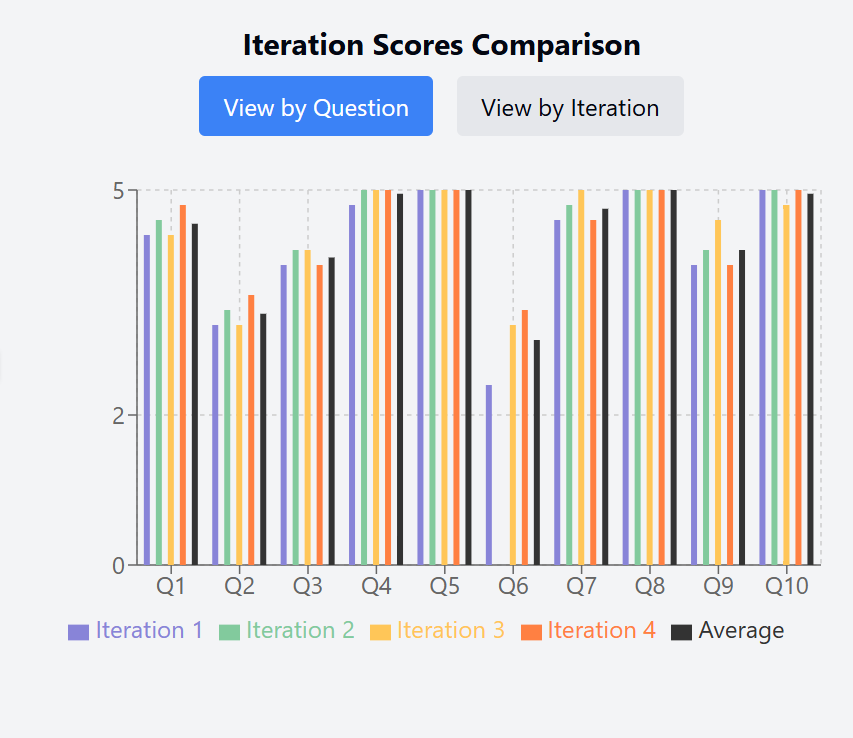

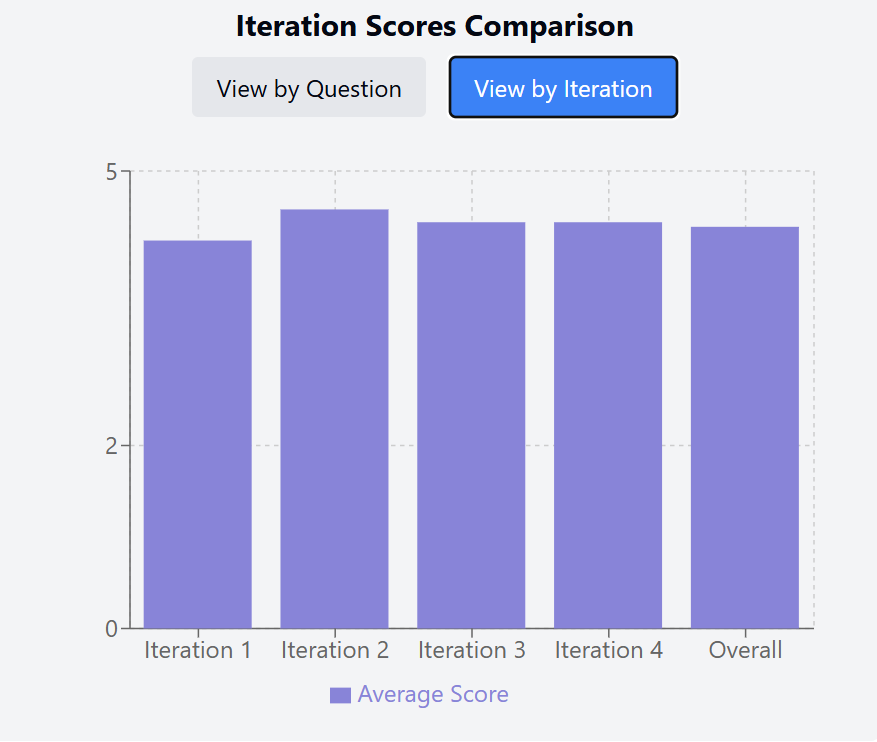